Configuring GPU settings...
✓ GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  GPU device name: /device:GPU:0

                 EXPERIMENT: DEEPER + FOCAL-EIOU + MC DROPOUT + ULTRA-MINIMAL CBAM                  
Loading train data...


I0000 00:00:1763379330.139508      38 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  train: 400 samples
Loading val data...
  val: 400 samples
Loading test data...
  test: 400 samples
Split - Train: 600, Val: 200, Test: 400

EXPERIMENT: FULL COMBINATION + ULTRA-MINIMAL CBAM (2 blocks: dec3+dec4)

TRAINING: FULL_with_ULTRA_MINIMAL_CBAM
  Focal-EIoU Loss: ✓
  Deeper Decoder: ✓
  MC Dropout: ✓ (rate=0.3)
  CBAM Attention: ✓ ULTRA-MINIMAL (2 blocks: dec3+dec4)

Building Combined UNet with ULTRA-MINIMAL CBAM...
  Deeper Architecture: True
  MC Dropout Rate: 0.3
  CBAM Attention: ULTRA-MINIMAL (2 blocks: decoder_3 & decoder_4 only)
  Building deeper decoder with ULTRA-MINIMAL CBAM...
    decoder_1: NO CBAM
    decoder_2: NO CBAM
    decoder_3: WITH CBAM ✓ (64x64 - critical for Disc/Cup)
    decoder_4: WITH CBAM ✓ (128x128 - fine boundaries)

  MC Dropout Configuration:
    Total Dropout Layers: 5
    Dropout Rates: ['0.30', '0.30', '0.30', '0.21', '0.15']

  CBAM Configuration (ULTRA-MINIMAL):
    Total CBAM Components: 6
    CBAM Locations: decoder_3 & decoder_4 ONLY (2 b

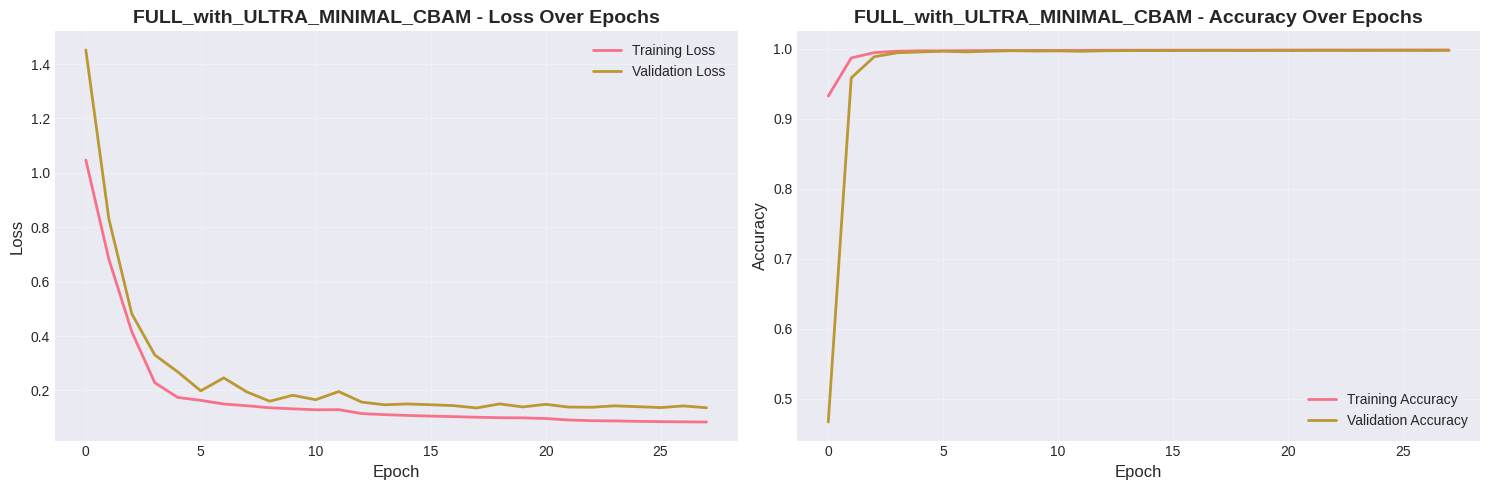


EVALUATION: Full with Ultra-Minimal CBAM
✓ Confusion matrices saved: results/Full with Ultra-Minimal CBAM_confusion_matrices.png


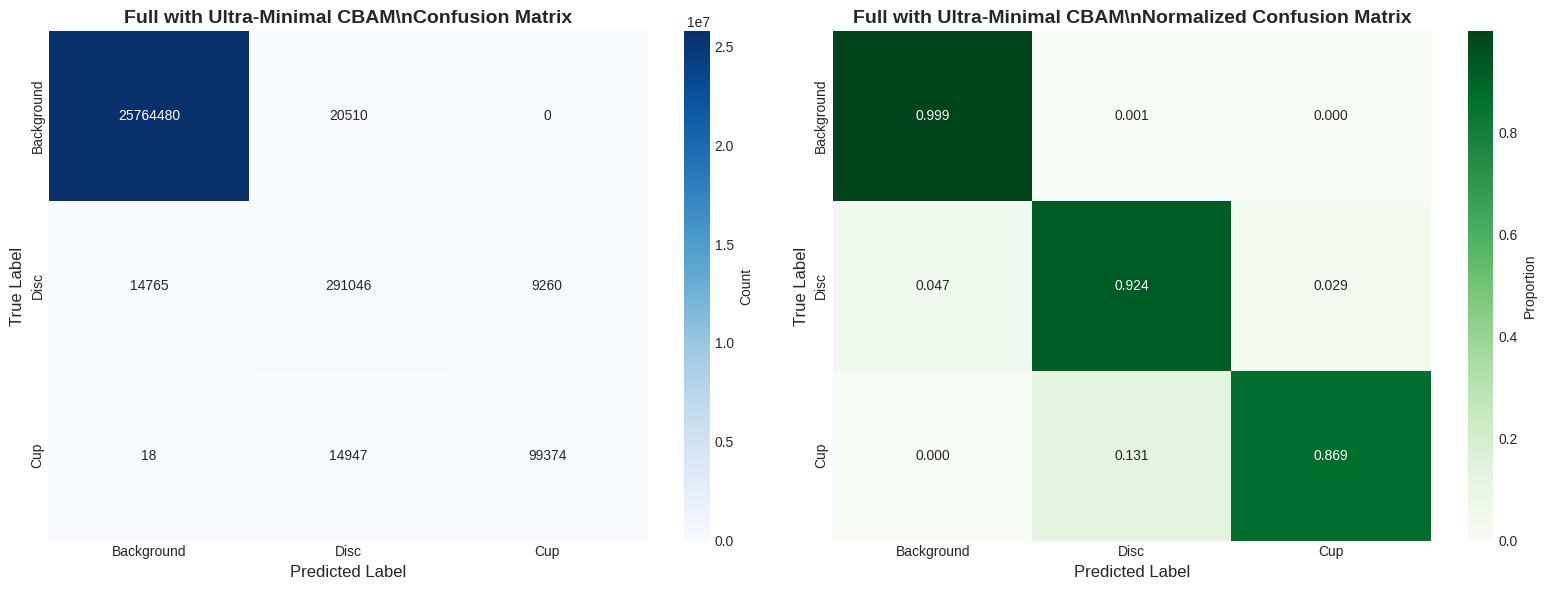

\nConfusion Matrix:
[[25764480    20510        0]
 [   14765   291046     9260]
 [      18    14947    99374]]
\nNormalized Confusion Matrix:
[[0.999 0.001 0.   ]
 [0.047 0.924 0.029]
 [0.    0.131 0.869]]

Precision, Recall, F1 Score per class:
  Background: Precision=0.9994, Recall=0.9992, F1=0.9993
  Disc: Precision=0.8914, Recall=0.9237, F1=0.9073
  Cup: Precision=0.9148, Recall=0.8691, F1=0.8914

Macro-averaged metrics:
  Precision: 0.9352
  Recall: 0.9307
  F1 Score: 0.9327
  Background: Dice=0.9993, IoU=0.9986
  Disc: Dice=0.9073, IoU=0.8303
  Cup: Dice=0.8914, IoU=0.8040

MC Dropout Evaluation:

Running MC Dropout with 10 stochastic forward passes...
  Completed: 5/10 forward passes
  Completed: 10/10 forward passes
✓ MC Dropout completed
  Background uncertainty: 0.0002
  Disc uncertainty: 0.0004
  Cup uncertainty: 0.0002

                                      ✓ EXPERIMENT COMPLETED!                                       

Final Results:

FULL + ULTRA-MINIMAL CBAM:
  Parameter

In [2]:
"""
COMBINED ADVANCED MOBILENET-UNET WITH ULTRA-MINIMAL CBAM ATTENTION
===================================================================
This combines:
1. Deeper decoder architecture with enhanced blocks
2. Focal-EIoU loss
3. MC Dropout for uncertainty estimation
4. CBAM (Convolutional Block Attention Module) - ULTRA-MINIMAL VERSION
   - Applied ONLY to: decoder_3 and decoder_4 (2 locations)
   - REMOVED from: skip connections, bridge, decoder_1, decoder_2, final layer
   - This targets attention ONLY where it matters most for Disc/Cup segmentation

STRATEGY: Place CBAM only in the final 2 decoder layers (decoder_3 at 64x64 
and decoder_4 at 128x128) where fine-grained Disc and Cup boundaries are refined.
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import albumentations as A
import warnings
import gc
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def configure_gpu():
    """Configure GPU settings for optimal performance"""
    print("Configuring GPU settings...")
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for gpu in physical_devices:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.config.set_visible_devices(physical_devices[0], 'GPU')
            print(f"✓ GPU found: {physical_devices}")
            print("  GPU device name:", tf.test.gpu_device_name())
            return True
        except RuntimeError as e:
            print(f"✗ GPU error: {e}")
            return False
    else:
        print("✗ No GPU found, using CPU")
        return False

def load_images_masks(images_folder, masks_folder, img_size=(256,256)):
    """Load images and masks from folders"""
    images, masks = [], []
    image_files = sorted(os.listdir(images_folder))
    mask_files = sorted(os.listdir(masks_folder))
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    
    for img_file in image_files:
        base = os.path.splitext(img_file)[0]
        if base in mask_dict:
            img = cv2.imread(os.path.join(images_folder, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size) / 255.0
            
            mask = cv2.imread(os.path.join(masks_folder, mask_dict[base]), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, img_size)
            unique_vals = np.unique(mask)
            if len(unique_vals) > 3 or np.max(unique_vals) > 2:
                mask = np.clip(mask // 85, 0, 2).astype(np.uint8)
            
            images.append(img)
            masks.append(mask)
    
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.uint8)

def load_all_data(root_dir):
    """Load all data from existing splits and merge"""
    all_images, all_masks = [], []
    for split in ["train", "val", "test"]:
        print(f"Loading {split} data...")
        imgs, msks = load_images_masks(
            os.path.join(root_dir, split, "Images"),
            os.path.join(root_dir, split, "Masks")
        )
        all_images.append(imgs)
        all_masks.append(msks)
        print(f"  {split}: {imgs.shape[0]} samples")
    
    return np.concatenate(all_images), np.concatenate(all_masks)

def create_new_split(all_images, all_masks):
    """Create new split: 600 train, 200 val, 400 test"""
    X_temp, X_test, y_temp, y_test = train_test_split(
        all_images, all_masks, test_size=400, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=200, random_state=42
    )
    print(f"Split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def setup_augmentations():
    return A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    ])

def data_generator(images, masks, batch_size, augment=None):
    idxs = np.arange(len(images))
    while True:
        np.random.shuffle(idxs)
        for i in range(0, len(images), batch_size):
            batch_idxs = idxs[i:i+batch_size]
            batch_x, batch_y = [], []
            
            for idx in batch_idxs:
                img, mask = images[idx], masks[idx]
                
                if augment:
                    aug = augment(image=img, mask=mask)
                    img_aug, mask_aug = aug['image'], aug['mask']
                else:
                    img_aug, mask_aug = img, mask
                
                mask_cat = to_categorical(mask_aug, num_classes=3)
                batch_x.append(img_aug)
                batch_y.append(mask_cat)
            
            batch_x = np.stack(batch_x).astype(np.float32)
            batch_y = np.stack(batch_y).astype(np.float32)
            
            yield batch_x, batch_y

# ============================================================================
# CBAM ATTENTION MODULES
# ============================================================================

def channel_attention(input_feature, ratio=8, name=""):
    """Channel Attention Module (CAM)"""
    channel = input_feature.shape[-1]
    
    shared_layer_one = layers.Dense(channel//ratio, activation='relu', name=f'channel_attention_dense1_{name}')
    shared_layer_two = layers.Dense(channel, activation='sigmoid', name=f'channel_attention_dense2_{name}')
    
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)
    
    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)
    
    cbam_feature = layers.Add()([avg_pool, max_pool])
    cbam_feature = layers.Multiply()([input_feature, cbam_feature])
    
    return cbam_feature

def spatial_attention(input_feature, name=""):
    """Spatial Attention Module (SAM)"""
    kernel_size = 7
    
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(input_feature)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(input_feature)
    concat = layers.Concatenate(axis=3)([avg_pool, max_pool])
    
    cbam_feature = layers.Conv2D(filters=1, kernel_size=kernel_size, strides=1, 
                                padding='same', activation='sigmoid', 
                                name=f'spatial_attention_conv_{name}')(concat)
    cbam_feature = layers.Multiply()([input_feature, cbam_feature])
    
    return cbam_feature

def cbam_block(cbam_feature, ratio=8, name=""):
    """CBAM: Convolutional Block Attention Module (Channel + Spatial)"""
    cbam_feature = channel_attention(cbam_feature, ratio, name=f"{name}_channel")
    cbam_feature = spatial_attention(cbam_feature, name=f"{name}_spatial")
    return cbam_feature

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

def focal_loss(y_true, y_pred, gamma=2.0, alpha=None, epsilon=1e-7):
    if alpha is None:
        alpha = [0.25, 1.0, 1.0]
    
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    focal_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        pt = y_pred_c
        focal_weight = K.pow(1.0 - pt, gamma)
        cross_entropy = -K.log(pt)
        focal_loss_c = alpha[c] * focal_weight * cross_entropy * y_true_c
        focal_loss_value += K.mean(focal_loss_c)
    
    return focal_loss_value

def enhanced_iou_loss(y_true, y_pred, smooth=1e-7):
    eiou_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        
        intersection = K.sum(y_true_c * y_pred_c, axis=[1, 2])
        union = K.sum(y_true_c, axis=[1, 2]) + K.sum(y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        
        height = K.cast(K.shape(y_true_c)[1], 'float32')
        width = K.cast(K.shape(y_true_c)[2], 'float32')
        
        y_coords = K.arange(0, height)
        x_coords = K.arange(0, width)
        y_grid = K.tile(K.reshape(y_coords, (-1, 1)), (1, K.cast(width, 'int32')))
        x_grid = K.tile(K.reshape(x_coords, (1, -1)), (K.cast(height, 'int32'), 1))
        y_grid = K.cast(y_grid, 'float32')
        x_grid = K.cast(x_grid, 'float32')
        
        true_mass = K.sum(y_true_c, axis=[1, 2]) + smooth
        true_center_y = K.sum(y_true_c * y_grid, axis=[1, 2]) / true_mass
        true_center_x = K.sum(y_true_c * x_grid, axis=[1, 2]) / true_mass
        
        pred_mass = K.sum(y_pred_c, axis=[1, 2]) + smooth
        pred_center_y = K.sum(y_pred_c * y_grid, axis=[1, 2]) / pred_mass
        pred_center_x = K.sum(y_pred_c * x_grid, axis=[1, 2]) / pred_mass
        
        center_distance = K.square(true_center_y - pred_center_y) + K.square(true_center_x - pred_center_x)
        diagonal = K.square(height) + K.square(width)
        center_penalty = center_distance / (diagonal + smooth)
        
        true_width = K.sqrt(K.sum(K.sum(y_true_c, axis=1), axis=1) + smooth)
        true_height = K.sqrt(K.sum(K.sum(y_true_c, axis=2), axis=1) + smooth)
        pred_width = K.sqrt(K.sum(K.sum(y_pred_c, axis=1), axis=1) + smooth)
        pred_height = K.sqrt(K.sum(K.sum(y_pred_c, axis=2), axis=1) + smooth)
        
        width_diff = K.square(pred_width - true_width)
        height_diff = K.square(pred_height - true_height)
        aspect_penalty = width_diff / (K.square(width) + smooth) + height_diff / (K.square(height) + smooth)
        
        eiou_c = 1.0 - iou + center_penalty + aspect_penalty
        eiou_loss_value += K.mean(eiou_c)
    
    return eiou_loss_value / 3.0

def focal_eiou_combined_loss(y_true, y_pred, focal_weight=1.0, eiou_weight=1.0, gamma=2.0, alpha=None):
    fl = focal_loss(y_true, y_pred, gamma=gamma, alpha=alpha)
    eiou = enhanced_iou_loss(y_true, y_pred)
    return focal_weight * fl + eiou_weight * eiou

# ============================================================================
# ENHANCED DECODER BLOCKS (WITH AND WITHOUT CBAM)
# ============================================================================

def enhanced_decoder_block_with_cbam(x, skip_connection, filters, block_name, dropout_rate=0.3):
    """Enhanced decoder block WITH CBAM attention"""
    x = layers.UpSampling2D((2, 2), name=f'{block_name}_upsample')(x)
    
    if skip_connection.shape[-1] != x.shape[-1]:
        skip_connection = layers.Conv2D(x.shape[-1], (1, 1), activation='relu', 
                                      padding='same', name=f'{block_name}_skip_align')(skip_connection)
        skip_connection = layers.BatchNormalization(name=f'{block_name}_skip_bn')(skip_connection)
    
    x = layers.Concatenate(name=f'{block_name}_concat')([x, skip_connection])
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv3')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn3')(x)
    
    residual = x
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv4')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn4')(x)
    
    x = layers.Add(name=f'{block_name}_residual')([x, residual])
    x = layers.Conv2D(filters, (1, 1), activation='relu', padding='same', name=f'{block_name}_conv_final')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn_final')(x)
    
    # CBAM attention
    x = cbam_block(x, ratio=8, name=block_name)
    
    return x

def enhanced_decoder_block_no_cbam(x, skip_connection, filters, block_name, dropout_rate=0.3):
    """Enhanced decoder block WITHOUT CBAM attention"""
    x = layers.UpSampling2D((2, 2), name=f'{block_name}_upsample')(x)
    
    if skip_connection.shape[-1] != x.shape[-1]:
        skip_connection = layers.Conv2D(x.shape[-1], (1, 1), activation='relu', 
                                      padding='same', name=f'{block_name}_skip_align')(skip_connection)
        skip_connection = layers.BatchNormalization(name=f'{block_name}_skip_bn')(skip_connection)
    
    x = layers.Concatenate(name=f'{block_name}_concat')([x, skip_connection])
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv3')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn3')(x)
    
    residual = x
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv4')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn4')(x)
    
    x = layers.Add(name=f'{block_name}_residual')([x, residual])
    x = layers.Conv2D(filters, (1, 1), activation='relu', padding='same', name=f'{block_name}_conv_final')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn_final')(x)
    
    # NO CBAM
    
    return x

# ============================================================================
# MODEL: ULTRA-MINIMAL CBAM (ONLY decoder_3 and decoder_4)
# ============================================================================

def build_combined_unet_ultra_minimal_cbam(input_shape=(256, 256, 3), num_classes=3, 
                                           use_deeper=False, dropout_rate=0.3):
    """
    Combined MobileNet-UNet with ULTRA-MINIMAL CBAM
    
    CBAM Placement (ULTRA-MINIMAL VERSION):
    - Skip connections: NO CBAM ❌
    - Bridge: NO CBAM ❌
    - Decoder_1 (8x8->16x16): NO CBAM ❌
    - Decoder_2 (16x16->32x32): NO CBAM ❌
    - Decoder_3 (32x32->64x64): YES ✅ (CRITICAL for Disc/Cup)
    - Decoder_4 (64x64->128x128): YES ✅ (CRITICAL for fine boundaries)
    - Final layer: NO CBAM ❌
    Total: 2 CBAM blocks (vs 10 in full, 4 in minimal)
    
    Rationale: decoder_3 and decoder_4 are the most important for segmenting
    small structures like optic disc and cup at 64x64 and 128x128 resolutions.
    """
    
    print(f"\nBuilding Combined UNet with ULTRA-MINIMAL CBAM...")
    print(f"  Deeper Architecture: {use_deeper}")
    print(f"  MC Dropout Rate: {dropout_rate}")
    print(f"  CBAM Attention: ULTRA-MINIMAL (2 blocks: decoder_3 & decoder_4 only)")
    
    inputs = layers.Input(input_shape, dtype='float32')
    backbone = MobileNetV2(input_tensor=inputs, weights='imagenet', include_top=False)
    
    skip_1 = backbone.get_layer('block_1_expand_relu').output  # 128x128
    skip_2 = backbone.get_layer('block_3_expand_relu').output  # 64x64
    skip_3 = backbone.get_layer('block_6_expand_relu').output  # 32x32
    skip_4 = backbone.get_layer('block_13_expand_relu').output # 16x16
    bridge = backbone.output  # 8x8
    
    # Deeper bridge (if enabled)
    if use_deeper:
        bridge = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(bridge)
        bridge = layers.BatchNormalization()(bridge)
    
    if dropout_rate > 0:
        bridge = layers.Dropout(dropout_rate, name='bridge_dropout')(bridge)
    
    if use_deeper:
        print("  Building deeper decoder with ULTRA-MINIMAL CBAM...")
        print("    decoder_1: NO CBAM")
        print("    decoder_2: NO CBAM")
        print("    decoder_3: WITH CBAM ✓ (64x64 - critical for Disc/Cup)")
        print("    decoder_4: WITH CBAM ✓ (128x128 - fine boundaries)")
        
        # Decoder_1: NO CBAM (8x8 -> 16x16)
        x = enhanced_decoder_block_no_cbam(bridge, skip_4, 512, 'decoder_1', dropout_rate)
        
        # Decoder_2: NO CBAM (16x16 -> 32x32)
        x = enhanced_decoder_block_no_cbam(x, skip_3, 256, 'decoder_2', dropout_rate)
        
        # Decoder_3: WITH CBAM ✓ (32x32 -> 64x64) - CRITICAL for Disc/Cup segmentation
        x = enhanced_decoder_block_with_cbam(x, skip_2, 128, 'decoder_3', dropout_rate * 0.7)
        
        # Decoder_4: WITH CBAM ✓ (64x64 -> 128x128) - Fine boundary refinement
        x = enhanced_decoder_block_with_cbam(x, skip_1, 64, 'decoder_4', dropout_rate * 0.5)
    else:
        print("  Building baseline decoder with ULTRA-MINIMAL CBAM...")
        # Baseline decoder_1: NO CBAM
        x = layers.UpSampling2D((2, 2))(bridge)
        x = layers.Concatenate()([x, skip_4])
        x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        # NO CBAM
        
        # Baseline decoder_2: NO CBAM
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip_3])
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        # NO CBAM
        
        # Baseline decoder_3: WITH CBAM
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip_2])
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate * 0.7)(x)
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = cbam_block(x, ratio=8, name="dec3")
        
        # Baseline decoder_4: WITH CBAM
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip_1])
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate * 0.5)(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = cbam_block(x, ratio=8, name="dec4")
    
    # Final upsampling - NO CBAM
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', dtype='float32')(x)
    
    model = models.Model(inputs, outputs)
    
    # Print configuration
    if dropout_rate > 0:
        dropout_layers = [layer for layer in model.layers if isinstance(layer, layers.Dropout)]
        print(f"\n  MC Dropout Configuration:")
        print(f"    Total Dropout Layers: {len(dropout_layers)}")
        print(f"    Dropout Rates: {[f'{layer.rate:.2f}' for layer in dropout_layers]}")
    
    cbam_count = sum(1 for layer in model.layers if 'channel_attention' in layer.name or 'spatial_attention' in layer.name)
    print(f"\n  CBAM Configuration (ULTRA-MINIMAL):")
    print(f"    Total CBAM Components: {cbam_count}")
    print(f"    CBAM Locations: decoder_3 & decoder_4 ONLY (2 blocks)")
    print(f"    Removed from: Skip connections, Bridge, decoder_1, decoder_2, Final layer")
    
    return model

# ============================================================================
# METRICS
# ============================================================================

def dice_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    return (2. * intersection + smooth) / (K.sum(y_true_class) + K.sum(y_pred_class) + smooth)

def dice_class_0(y_true, y_pred): return dice_coef_class(y_true, y_pred, 0)
def dice_class_1(y_true, y_pred): return dice_coef_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_coef_class(y_true, y_pred, 2)

def iou_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    union = K.sum(y_true_class) + K.sum(y_pred_class) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_class_0(y_true, y_pred): return iou_coef_class(y_true, y_pred, 0)
def iou_class_1(y_true, y_pred): return iou_coef_class(y_true, y_pred, 1)
def iou_class_2(y_true, y_pred): return iou_coef_class(y_true, y_pred, 2)

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_training_history(history, model_name, save_dir='results'):
    """Plot training history: loss and accuracy curves"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title(f'{model_name} - Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_training_curves.png", dpi=300, bbox_inches='tight')
    print(f"\u2713 Training curves saved: {save_dir}/{model_name}_training_curves.png")
    plt.show()
    plt.close()

def plot_confusion_matrices(y_true, y_pred, model_name, save_dir='results'):
    """Plot confusion matrix and normalized confusion matrix"""
    y_true_labels = np.argmax(y_true, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    class_names = ['Background', 'Disc', 'Cup']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'{model_name}\\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Proportion'})
    axes[1].set_title(f'{model_name}\\nNormalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion_matrices.png", dpi=300, bbox_inches='tight')
    print(f"\u2713 Confusion matrices saved: {save_dir}/{model_name}_confusion_matrices.png")
    plt.show()
    plt.close()
    
    print(f"\\nConfusion Matrix:")
    print(cm)
    print(f"\\nNormalized Confusion Matrix:")
    print(np.round(cm_normalized, 3))
    
    return cm, cm_normalized

# ============================================================================
# MC DROPOUT
# ============================================================================

def mc_dropout_predict(model, X, num_samples=15, batch_size=4, verbose=True):
    """MC Dropout prediction using training=True flag"""
    if verbose:
        print(f"\nRunning MC Dropout with {num_samples} stochastic forward passes...")
    
    predictions = []
    num_batches = int(np.ceil(len(X) / batch_size))
    
    for i in range(num_samples):
        if verbose and (i + 1) % 5 == 0:
            print(f"  Completed: {i+1}/{num_samples} forward passes")
        
        batch_preds = []
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(X))
            X_batch = X[start_idx:end_idx]
            
            pred_batch = model(X_batch, training=True)
            batch_preds.append(pred_batch.numpy())
        
        pred = np.concatenate(batch_preds, axis=0)
        predictions.append(pred)
        
        if (i + 1) % 5 == 0:
            gc.collect()
    
    all_preds = np.array(predictions)
    mean_pred = np.mean(all_preds, axis=0)
    std_pred = np.std(all_preds, axis=0)
    
    del all_preds
    gc.collect()
    
    if verbose:
        print(f"✓ MC Dropout completed")
    
    return mean_pred, std_pred

# ============================================================================
# TRAINING
# ============================================================================

def train_model(X_train, y_train, X_val, y_val, X_test, y_test, model_name, 
               use_focal_eiou=False, use_deeper=False, dropout_rate=0.0,
               augment=None, save_dir='results'):
    """Train model with ultra-minimal CBAM"""
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    print(f"  Focal-EIoU Loss: {'✓' if use_focal_eiou else '✗'}")
    print(f"  Deeper Decoder: {'✓' if use_deeper else '✗'}")
    print(f"  MC Dropout: {'✓ (rate=' + str(dropout_rate) + ')' if dropout_rate > 0 else '✗'}")
    print(f"  CBAM Attention: ✓ ULTRA-MINIMAL (2 blocks: dec3+dec4)")
    
    K.clear_session()
    
    model = build_combined_unet_ultra_minimal_cbam(use_deeper=use_deeper, dropout_rate=dropout_rate)
    
    param_count = model.count_params()
    print(f"  Total Parameters: {param_count:,}")
    
    if use_focal_eiou:
        loss_fn = focal_eiou_combined_loss
    else:
        loss_fn = "categorical_crossentropy"
    
    initial_lr = 5e-4 if use_deeper else 1e-3
    model.compile(
        optimizer=optimizers.Adam(learning_rate=initial_lr),
        loss=loss_fn,
        metrics=[dice_coef_multiclass, dice_class_0, dice_class_1, dice_class_2,
                "accuracy", iou_coef_multiclass, iou_class_0, iou_class_1, iou_class_2]
    )
    
    checkpoint = ModelCheckpoint(f"{save_dir}/{model_name}.keras", save_best_only=True, verbose=1, 
                                monitor='val_loss', mode='min')
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, 
                                  verbose=1, mode='min', min_lr=1e-7)
    early_stop = EarlyStopping(monitor="val_loss", patience=10, verbose=1, 
                              restore_best_weights=True, mode='min')
    
    batch_size = 4 if use_deeper else 6
    steps_train = X_train.shape[0] // batch_size
    steps_val = X_val.shape[0] // batch_size
    
    try:
        history = model.fit(
            data_generator(X_train, y_train, batch_size, augment),
            validation_data=data_generator(X_val, y_val, batch_size, None),
            steps_per_epoch=steps_train,
            validation_steps=steps_val,
            epochs=50,
            callbacks=[checkpoint, reduce_lr, early_stop],
            verbose=1
        )
    except Exception as e:
        print(f"✗ Error: {e}. Retrying with smaller batch...")
        batch_size = 2 if use_deeper else 4
        steps_train = X_train.shape[0] // batch_size
        steps_val = X_val.shape[0] // batch_size
        
        history = model.fit(
            data_generator(X_train, y_train, batch_size, augment),
            validation_data=data_generator(X_val, y_val, batch_size, None),
            steps_per_epoch=steps_train,
            validation_steps=steps_val,
            epochs=50,
            callbacks=[checkpoint, reduce_lr, early_stop],
            verbose=1
        )
    
    print(f" Training completed")
    
    plot_training_history(history, model_name, save_dir)
    
    return model, history, param_count

# ============================================================================
# EVALUATION
# ============================================================================

def evaluate_model(model, X_test, y_test, model_name, run_mc_dropout=False, save_dir='results'):
    """Evaluate model"""
    print(f"\n{'='*80}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*80}")
    
    y_test_cat = np.array([to_categorical(mask, num_classes=3) for mask in y_test])
    
    test_metrics = model.evaluate(X_test, y_test_cat, verbose=0, batch_size=4)
    y_pred = model.predict(X_test, verbose=0, batch_size=4)
    
    plot_confusion_matrices(y_test_cat, y_pred, model_name, save_dir)
    
    # Calculate precision, recall, F1 score
    y_true_labels = np.argmax(y_test_cat, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    precision = precision_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    
    print(f"\nPrecision, Recall, F1 Score per class:")
    class_names = ["Background", "Disc", "Cup"]
    for idx, cname in enumerate(class_names):
        print(f"  {cname}: Precision={precision[idx]:.4f}, Recall={recall[idx]:.4f}, F1={f1[idx]:.4f}")
    
    print(f"\nMacro-averaged metrics:")
    print(f"  Precision: {np.mean(precision):.4f}")
    print(f"  Recall: {np.mean(recall):.4f}")
    print(f"  F1 Score: {np.mean(f1):.4f}")
    
    class_names = ["Background", "Disc", "Cup"]
    results = {'standard': {}}
    
    for cidx, cname in enumerate(class_names):
        y_true_c = (np.argmax(y_test_cat, axis=-1) == cidx).astype(np.float32)
        y_pred_c = (np.argmax(y_pred, axis=-1) == cidx).astype(np.float32)
        
        intersection = np.sum(y_true_c * y_pred_c)
        dice = (2. * intersection + 1e-7) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)
        union = np.sum(y_true_c) + np.sum(y_pred_c) - intersection
        iou = (intersection + 1e-7) / (union + 1e-7)
        
        results['standard'][cname] = {'dice': dice, 'iou': iou}
        print(f"  {cname}: Dice={dice:.4f}, IoU={iou:.4f}")
    
    if run_mc_dropout:
        print("\nMC Dropout Evaluation:")
        mean_pred, std_pred = mc_dropout_predict(model, X_test[:100], num_samples=10, verbose=True)
        results['mc_dropout'] = {}
        for cidx, cname in enumerate(class_names):
            mean_std = np.mean(std_pred[:, :, :, cidx])
            results['mc_dropout'][cname] = {'mean_uncertainty': mean_std}
            print(f"  {cname} uncertainty: {mean_std:.4f}")
    
    return results

# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    gpu_available = configure_gpu()
    root_dir = "/kaggle/input/refuge/REFUGE/"
    train_aug = setup_augmentations()
    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n{'='*100}")
    print(f"{'EXPERIMENT: DEEPER + FOCAL-EIOU + MC DROPOUT + ULTRA-MINIMAL CBAM':^100s}")
    print(f"{'='*100}")
    
    all_images, all_masks = load_all_data(root_dir)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = create_new_split(all_images, all_masks)
    
    all_results = {}
    all_params = {}
    
    print(f"\n{'='*80}")
    print("EXPERIMENT: FULL COMBINATION + ULTRA-MINIMAL CBAM (2 blocks: dec3+dec4)")
    print(f"{'='*80}")
    
    model, history, params = train_model(
        X_train, y_train, X_val, y_val, X_test, y_test,
        "FULL_with_ULTRA_MINIMAL_CBAM",
        use_focal_eiou=True, use_deeper=True, dropout_rate=0.3,
        augment=train_aug, save_dir=save_dir
    )
    
    all_results['FULL + ULTRA-MINIMAL CBAM'] = evaluate_model(model, X_test, y_test, "Full with Ultra-Minimal CBAM", run_mc_dropout=True, save_dir=save_dir)
    all_params['FULL + ULTRA-MINIMAL CBAM'] = params
    
    print(f"\n{'='*100}")
    print(f"{'✓ EXPERIMENT COMPLETED!':^100s}")
    print(f"{'='*100}")
    
    print("\nFinal Results:")
    for model_name, results in all_results.items():
        disc_dice = results['standard']['Disc']['dice']
        cup_dice = results['standard']['Cup']['dice']
        print(f"\n{model_name}:")
        print(f"  Parameters: {all_params[model_name]:,}")
        print(f"  Disc Dice: {disc_dice:.4f}")
        print(f"  Cup Dice: {cup_dice:.4f}")
        print(f"  Overall: {(disc_dice + cup_dice)/2:.4f}")
    
    print(f"\n{'='*100}\n")
